# 04 - Stage 3: Failure-Mode Classification

The final stage answers *why* a pump is degrading: **Mechanical** wear/vibration vs.
**Chemical** (corrosive/abrasive water quality) vs. **Normal**. Component C's target
design shares an encoder between RUL and classification; this prototype keeps the two
stages conceptually linked by feeding the classifier the *same* representation
(engineered features + Stage 1 health score) used for RUL, via
`src/models/classifier.py`.

In [1]:
import sys, os
sys.path.append(os.path.abspath('..'))
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')
%matplotlib inline

from src import config, data_loader, preprocessing, evaluate

from src.models.autoencoder import AnomalyAutoencoder
from src.models.classifier import FailureModeClassifier

## Rebuild Stage 1 to get the shared feature representation

In [2]:
variant = 'variant3'
df = data_loader.load_variant(variant)
splits = data_loader.split_by_time(df)
feature_cols = config.FEATURE_COLS[variant]

scaler = preprocessing.fit_scaler(splits['train'], feature_cols)
X_train_win, X_train_last, meta_train = preprocessing.build_windows(splits['train'], feature_cols, scaler)
X_test_win, X_test_last, meta_test = preprocessing.build_windows(splits['test'], feature_cols, scaler)

healthy_mask = (meta_train['failure_mode_label'] == 'Normal').values
autoencoder = AnomalyAutoencoder(input_dim=X_train_win.shape[1]).fit(X_train_win[healthy_mask])
health_train = autoencoder.reconstruction_error(X_train_win)
health_test = autoencoder.reconstruction_error(X_test_win)

X_clf_train = np.hstack([X_train_last, health_train.reshape(-1, 1)])
X_clf_test = np.hstack([X_test_last, health_test.reshape(-1, 1)])
y_clf_train = meta_train['failure_mode_label'].values
y_clf_test = meta_test['failure_mode_label'].values

## Train the classifier and evaluate

In [3]:
classifier = FailureModeClassifier().fit(X_clf_train, y_clf_train)
y_pred = classifier.predict(X_clf_test)
y_proba = classifier.predict_proba(X_clf_test)

m = evaluate.classification_metrics(y_clf_test, y_pred, config.FAILURE_MODE_CLASSES)
print(f"Accuracy: {m['accuracy']:.3f}   Macro-F1: {m['f1_macro']:.3f}\n")
pd.DataFrame(m['report']).T

Accuracy: 0.951   Macro-F1: 0.949



,precision,recall,f1-score,support
Normal,0.917683,1.000000,0.957075,301.000000
Mechanical,1.000000,0.904669,0.949949,514.000000
Chemical,0.888889,1.000000,0.941176,176.000000
accuracy,0.950555,0.950555,0.950555,0.950555
macro avg,0.935524,0.968223,0.949400,991.000000
weighted avg,0.955264,0.950555,0.950555,991.000000


## Confusion matrix

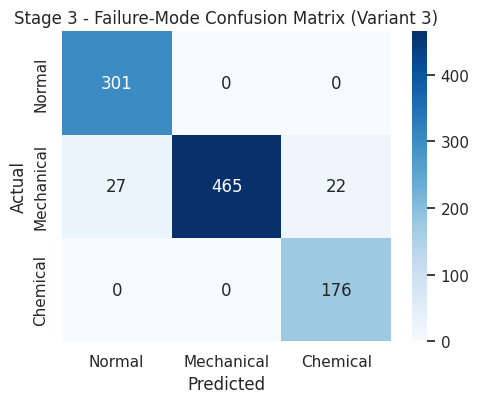

In [4]:
cm = np.array(m['confusion_matrix'])
fig, ax = plt.subplots(figsize=(5, 4.2))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=m['labels'], yticklabels=m['labels'], ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Stage 3 - Failure-Mode Confusion Matrix (Variant 3)')
plt.tight_layout()
plt.show()

## A worked example: probability breakdown for a handful of test windows

In [5]:
proba_df = pd.DataFrame(y_proba, columns=[f'proba_{c}' for c in classifier.classes_])
example = meta_test[['pump_id', 'timestamp', 'failure_mode_label']].reset_index(drop=True)
example = pd.concat([example, proba_df], axis=1)
example['predicted'] = y_pred
example.sample(10, random_state=1).sort_values('timestamp')

,pump_id,timestamp,failure_mode_label,proba_Chemical,proba_Mechanical,proba_Normal,predicted
658,PUMP_03,2026-04-23 00:00:00,Chemical,0.816667,0.043333,0.140000,Chemical
678,PUMP_03,2026-04-23 20:00:00,Chemical,0.833333,0.013333,0.153333,Chemical
680,PUMP_03,2026-04-23 22:00:00,Chemical,0.840000,0.013333,0.146667,Chemical
301,PUMP_02,2026-04-30 11:00:00,Mechanical,0.106667,0.596667,0.296667,Mechanical
335,PUMP_02,2026-05-01 21:00:00,Mechanical,0.160000,0.496667,0.343333,Mechanical
726,PUMP_04,2026-05-14 00:00:00,Mechanical,0.010000,0.946667,0.043333,Mechanical
804,PUMP_04,2026-05-17 06:00:00,Mechanical,0.023333,0.943333,0.033333,Mechanical
94,PUMP_01,2026-05-21 09:00:00,Normal,0.013333,0.003333,0.983333,Normal
108,PUMP_01,2026-05-21 23:00:00,Normal,0.020000,0.016667,0.963333,Normal
236,PUMP_01,2026-05-27 07:00:00,Normal,0.003333,0.013333,0.983333,Normal


**Takeaway:** classification is where fusing water-quality data matters most - a mechanical-only model structurally cannot tell a chemical failure from a mechanical one. That comparison is quantified properly in the next notebook: `05_three_variant_comparison.ipynb`.